# YouTube Analytics & Channel Benchmarking
### A Data Science Approach to Content Strategy for Moroccan YouTube Creators

## Project Overview

This notebook presents a structured analysis of YouTube content performance across multiple Moroccan/Arabic-speaking YouTube channels. The project is organized into five major sections:

1. **Feature Engineering** — Deriving engagement, temporal, and text-based features
2. **Exploratory Data Analysis (EDA)** — Market-level insights on formats and timing
3. **Channel Clustering** — Discovering content strategy archetypes
4. **Micro-Benchmark** — Positioning the channel *BIMO* against its competitive niche
5. **NLP Title Analysis** — Identifying linguistic patterns in high-performing videos


## 0. Environment Setup & Imports

In [1]:
# ── Core libraries ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import re
import unicodedata

# ── Machine learning ──────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ── NLP ───────────────────────────────────────────────────────────────────────
from collections import Counter
from wordcloud import WordCloud

# ── Display settings ──────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Plot theme ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

print('✅ Environment ready.')

✅ Environment ready.


## 1. Data Loading & Initial Cleaning

In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('dataset_total.csv', encoding='utf-8')
df


,position,channelId,channelTitle,videoId,publishedAt,publishedAtSQL,videoTitle,videoDescription,tags,videoCategoryId,videoCategoryLabel,topicCategories,duration,durationSec,dimension,definition,caption,defaultLanguage,defaultLAudioLanguage,thumbnail_maxres,licensedContent,hasPaidProductPlacement,locationDescription,latitude,longitude,viewCount,likeCount,dislikeCount,favoriteCount,commentCount
0,1,UCC4PkXCup_rjEjyGfsYYmpg,Ahmed Sabiri 2.0,6vGkHVs4GXs,2026-04-24T18:00:24Z,2026-04-24 18:00:24,قبضت علي الشرطة الفرنسية,Live f Kick Koula nhar m3a 22.30h derbou follo...,"ahmedsabiri,storytime,sabiri,ahmedsabiristory,...",22,People & Blogs,Society,PT16M23S,983,2d,hd,False,en,ar,https://i.ytimg.com/vi/6vGkHVs4GXs/maxresdefau...,1.0000,NaN,NaN,NaN,NaN,84831,6851.0000,NaN,0,663.0000
1,2,UCC4PkXCup_rjEjyGfsYYmpg,Ahmed Sabiri 2.0,1j_F1sYyI_Y,2026-04-19T14:00:54Z,2026-04-19 14:00:54,أكل الشوارع في مدينة مدريد | Madrid Street Foo...,Live f Kick Koula nhar m3a 21.30 h Ajiw Marhba...,"ahmedsabiri,storytime,sabiri,ahmedsabiristory,...",22,People & Blogs,"Food,Lifestyle_(sociology)",PT32M23S,1943,2d,hd,False,en,ar,https://i.ytimg.com/vi/1j_F1sYyI_Y/maxresdefau...,1.0000,NaN,NaN,NaN,NaN,248408,11249.0000,NaN,0,729.0000
2,3,UCC4PkXCup_rjEjyGfsYYmpg,Ahmed Sabiri 2.0,17Q_qONMcTU,2026-04-15T17:15:30Z,2026-04-15 17:15:30,🤕 تبخر الحلم مرة اخرى، دوروني المشجعين ديال ات...,Live f Kick Koula nhar m3a 21.30 h Ajiw Marhba...,"ahmedsabiri,storytime,sabiri,ahmedsabiristory,...",22,People & Blogs,"Association_football,Lifestyle_(sociology)",PT36M29S,2189,2d,hd,False,ar,ar,https://i.ytimg.com/vi/17Q_qONMcTU/maxresdefau...,1.0000,NaN,NaN,NaN,NaN,134770,5440.0000,NaN,0,1609.0000
3,4,UCC4PkXCup_rjEjyGfsYYmpg,Ahmed Sabiri 2.0,n62aZPiOMe0,2026-04-14T22:02:16Z,2026-04-14 22:02:16,"De3na a chabab, visca barça💙❤️",NaN,NaN,22,People & Blogs,"Association_football,Sport",PT12S,12,2d,hd,False,es,ar,https://i.ytimg.com/vi/n62aZPiOMe0/maxresdefau...,1.0000,NaN,NaN,NaN,NaN,54466,1702.0000,NaN,0,225.0000
4,5,UCC4PkXCup_rjEjyGfsYYmpg,Ahmed Sabiri 2.0,HIrKF04VzHg,2026-03-18T18:00:41Z,2026-03-18 18:00:41,Ahmedsabiri Réaction - 🏆🦁 أخيرا المغرب بطل إفر...,Live f Kick Koula nhar m3a 21.30 h Ajiw Marhba...,"ahmedsabiri,storytime,sabiri,ahmedsabiristory,...",22,People & Blogs,"Association_football,Sport",PT27M16S,1636,2d,hd,False,fr,ar,https://i.ytimg.com/vi/HIrKF04VzHg/maxresdefau...,1.0000,NaN,NaN,NaN,NaN,162552,6243.0000,NaN,0,531.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32400,122,UChOoQb2-j2adGHoi-OPxQQQ,Zizou Vlogs,3eQfAJMIwUQ,2020-11-13T17:30:19Z,2020-11-13 17:30:19,مشيت لجزيرة النساء وخلقنا السعادة معا تيتيز ال...,تابعوني على تطبيق YouNow كل يوم بث ⬇️ https://...,"Zizou vlogs,Hamada chroukate,Fayssal vlog,Fays...",22,People & Blogs,"Lifestyle_(sociology),Tourism",PT21M24S,1284,2d,hd,False,ar,en,https://i.ytimg.com/vi/3eQfAJMIwUQ/maxresdefau...,1.0000,NaN,NaN,NaN,NaN,396394,11596.0000,NaN,0,668.0000
32401,123,UChOoQb2-j2adGHoi-OPxQQQ,Zizou Vlogs,GbhCqxcNbxQ,2020-11-09T19:13:48Z,2020-11-09 19:13:48,حياة الليل فلاس فيغاس ديال المكسيك 😱 | Mexico ...,Aتابعوني على الانستغرام FOLLOW ME ON INSTAGRAM...,"Hassan diae vlogs,Mourad Mzouri vlogs,Aymane s...",22,People & Blogs,"Lifestyle_(sociology),Tourism",PT22M13S,1333,2d,hd,False,ar,en,https://i.ytimg.com/vi/GbhCqxcNbxQ/maxresdefau...,1.0000,NaN,NaN,NaN,NaN,284940,9214.0000,NaN,0,638.0000
32402,124,UChOoQb2-j2adGHoi-OPxQQQ,Zizou Vlogs,A-FIGii4ho8,2020-11-03T22:32:04Z,2020-11-03 22:32:04,Transmisión en vivo de Zizou Vlogs,NaN,NaN,22,People & Blogs,NaN,P0D,0,2d,sd,False,es,en,https://i.ytimg.com/vi/A-FIGii4ho8/maxresdefau...,1.0000,NaN,NaN,NaN,NaN,0,4.0000,NaN,0,0.0000
32403,125,UChOoQb2-j2adGHoi-OPxQQQ,Zizou Vlogs,o9dYvTlsihE,2020-08-11T14:41:53Z,2020-08-11 14:41:53,درت مشروع ديال الهندية فالمكسيك بزيرو درهم شوف...,MY INSTAGRAM : zizouvlogs هدا الانستغرام ديال ...,"hassan diae vlogs,taha essou,niba tbib,hamada ...",22,People & Blogs,"Hobby,Lifestyle_(s

In [3]:
df.columns

Index(['position', 'channelId', 'channelTitle', 'videoId', 'publishedAt',
       'publishedAtSQL', 'videoTitle', 'videoDescription', 'tags',
       'videoCategoryId', 'videoCategoryLabel', 'topicCategories', 'duration',
       'durationSec', 'dimension', 'definition', 'caption', 'defaultLanguage',
       'defaultLAudioLanguage', 'thumbnail_maxres', 'licensedContent',
       'hasPaidProductPlacement', 'locationDescription', 'latitude',
       'longitude', 'viewCount', 'likeCount', 'dislikeCount', 'favoriteCount',
       'commentCount'],
      dtype='object')

In [4]:
#determiner les valeurs de licensedContent pour voir si on peut les remplacer par le mode
df['licensedContent'].value_counts(dropna=False)

licensedContent
1.0000    30836
NaN        1569
Name: count, dtype: int64

In [5]:

# Strip whitespace from string columns
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda c: c.str.strip() if c.dtype == 'object' else c)

print(f'Dataset shape: {df.shape}')
print(f'Channels     : {df["channelTitle"].nunique()}')
print(f'Date range   : {df["publishedAtSQL"].min()} → {df["publishedAtSQL"].max()}')
df.head(3)

Dataset shape: (32405, 30)
Channels     : 21
Date range   : 2013-10-20 19:31:20 → 2026-04-26 15:42:14


,position,channelId,channelTitle,videoId,publishedAt,publishedAtSQL,videoTitle,videoDescription,tags,videoCategoryId,videoCategoryLabel,topicCategories,duration,durationSec,dimension,definition,caption,defaultLanguage,defaultLAudioLanguage,thumbnail_maxres,licensedContent,hasPaidProductPlacement,locationDescription,latitude,longitude,viewCount,likeCount,dislikeCount,favoriteCount,commentCount
0,1,UCC4PkXCup_rjEjyGfsYYmpg,Ahmed Sabiri 2.0,6vGkHVs4GXs,2026-04-24T18:00:24Z,2026-04-24 18:00:24,قبضت علي الشرطة الفرنسية,Live f Kick Koula nhar m3a 22.30h derbou follo...,"ahmedsabiri,storytime,sabiri,ahmedsabiristory,...",22,People & Blogs,Society,PT16M23S,983,2d,hd,False,en,ar,https://i.ytimg.com/vi/6vGkHVs4GXs/maxresdefau...,1.0000,NaN,NaN,NaN,NaN,84831,6851.0000,NaN,0,663.0000
1,2,UCC4PkXCup_rjEjyGfsYYmpg,Ahmed Sabiri 2.0,1j_F1sYyI_Y,2026-04-19T14:00:54Z,2026-04-19 14:00:54,أكل الشوارع في مدينة مدريد | Madrid Street Foo...,Live f Kick Koula nhar m3a 21.30 h Ajiw Marhba...,"ahmedsabiri,storytime,sabiri,ahmedsabiristory,...",22,People & Blogs,"Food,Lifestyle_(sociology)",PT32M23S,1943,2d,hd,False,en,ar,https://i.ytimg.com/vi/1j_F1sYyI_Y/maxresdefau...,1.0000,NaN,NaN,NaN,NaN,248408,11249.0000,NaN,0,729.0000
2,3,UCC4PkXCup_rjEjyGfsYYmpg,Ahmed Sabiri 2.0,17Q_qONMcTU,2026-04-15T17:15:30Z,2026-04-15 17:15:30,🤕 تبخر الحلم مرة اخرى، دوروني المشجعين ديال ات...,Live f Kick Koula nhar m3a 21.30 h Ajiw Marhba...,"ahmedsabiri,storytime,sabiri,ahmedsabiristory,...",22,People & Blogs,"Association_football,Lifestyle_(sociology)",PT36M29S,2189,2d,hd,False,ar,ar,https://i.ytimg.com/vi/17Q_qONMcTU/maxresdefau...,1.0000,NaN,NaN,NaN,NaN,134770,5440.0000,NaN,0,1609.0000


In [6]:
# ── Missing values summary ────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing': missing, '%': missing_pct})
missing_report[missing_report['missing'] > 0].sort_values('%', ascending=False)

,missing,%
dislikeCount,32405,100.0000
hasPaidProductPlacement,32324,99.7500
locationDescription,31981,98.6900
latitude,31981,98.6900
longitude,31981,98.6900
topicCategories,11280,34.8100
tags,10857,33.5000
videoDescription,4113,12.6900
thumbnail_maxres,1802,5.5600
licensedContent,1569,4.8400


In [7]:
# supprimer les colonnes avec trop de valeurs manquantes ou peu pertinentes dans ce cas on enleve 
# les colonnes suivantes : 'dislikeCount', 'locationDescription', 'latitude', 'longitude', 'hasPaidProductPlacement'
df = df.drop(columns=['dislikeCount', 'locationDescription', 'latitude', 'longitude', 'hasPaidProductPlacement'])

# Fill key numeric columns with 0 when missing
for col in ['viewCount', 'likeCount', 'commentCount', 'durationSec']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    



# Parse datetime
df['publishedAtSQL'] = pd.to_datetime(df['publishedAtSQL'], errors='coerce')

# Drop rows without a valid published date or video title
df = df.dropna(subset=['publishedAtSQL', 'videoTitle'])


In [8]:
# likeCount (0.17%) et commentCount (0.16%)
df['likeCount'] = df['likeCount'].fillna(0)
df['commentCount'] = df['commentCount'].fillna(0)

In [9]:
# Remplacer les valeurs manquantes (NaN) par 0 (False)
df['licensedContent'] = df['licensedContent'].fillna(0)

# Optionnel mais recommandé : Convertir la colonne en entier (0 et 1) pour gagner de la mémoire
df['licensedContent'] = df['licensedContent'].astype(int)

# Vérification
print(df['licensedContent'].value_counts())

licensedContent
1    30836
0     1569
Name: count, dtype: int64


In [10]:

# Fill text columns
df['videoTitle'] = df['videoTitle'].fillna('')
df['tags']       = df['tags'].fillna('')
# Option de nettoyage simple
df['topicCategories'] = df['topicCategories'].fillna('Unknown')

print(f'Clean dataset shape: {df.shape}')

Clean dataset shape: (32405, 25)


In [35]:
df.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
position,32405.0000,NaN,NaN,NaN,225.9509,1.0000,82.0000,181.0000,324.0000,847.0000,179.4063
channelId,32405,21,UCv6T1ljYi3CETJ1Jqj1bFMQ,4662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channelTitle,32405,21,Farouk Life,4662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
videoId,32405,6653,ekKXDfU7A5M,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publishedAt,32405,6652,2025-08-23T11:01:26Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
publishedAtSQL,32405,NaN,NaN,NaN,2023-06-07 04:51:37.916679680,2013-10-20 19:31:20,2022-03-28 15:42:58,2023-11-05 18:27:11,2025-01-14 20:35:39,2026-04-26 15:42:14,NaN
videoTitle,32405,6643,CALL OF DUTY MOBILE | الطريق نحو الاحتراف,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
videoDescription,28292,2402,مرحبا بكم في القناة، الاسم ديالي سكينة و اليوم...,1015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tags,32405,2061,,10857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
videoCategoryId,32405.0000,NaN,NaN,NaN,23.3503,1.0000,22.0000,24.0000,24.0000,29.0000,2.0595


---

## STEP 1 — Feature Engineering

We enrich the raw dataset with derived features across four dimensions:
- **Engagement** — Ratios capturing audience interaction intensity
- **Temporal** — Publishing time patterns
- **Format** — Video length classification
- **Text / NLP** — Title and tag characteristics

### 1.1 Engagement Features

In [11]:
# ── Engagement rate = (likes + comments) / views ─────────────────────────────
# np.where guards against division by zero; result capped at 1 to remove anomalies
df['engagement_rate'] = np.where(
    df['viewCount'] > 0,
    (df['likeCount'] + df['commentCount']) / df['viewCount'],
    0
).clip(0, 1)

# ── Like ratio = likes / views ────────────────────────────────────────────────
df['like_ratio'] = np.where(
    df['viewCount'] > 0,
    df['likeCount'] / df['viewCount'],
    0
).clip(0, 1)

print('Engagement features created.')
df[['viewCount', 'likeCount', 'commentCount', 'engagement_rate', 'like_ratio']].describe()

Engagement features created.


,viewCount,likeCount,commentCount,engagement_rate,like_ratio
count,32405.0000,32405.0000,32405.0000,32405.0000,32405.0000
mean,589091.6218,29929.0941,1448.8210,0.0583,0.0555
std,766750.1807,36667.7323,2340.3106,0.0300,0.0283
min,0.0000,0.0000,0.0000,0.0000,0.0000
25%,165333.0000,7784.0000,314.0000,0.0388,0.0369
50%,344883.0000,18158.0000,744.0000,0.0514,0.0492
75%,728302.0000,37741.0000,1654.0000,0.0696,0.0666
max,13923583.0000,667621.0000,57354.0000,0.3049,0.2799


### 1.2 Temporal Features

In [12]:
# ── Extract temporal dimensions from publish timestamp ────────────────────────
df['publish_hour'] = df['publishedAtSQL'].dt.hour
df['publish_day']  = df['publishedAtSQL'].dt.day_name()   # e.g. 'Monday'
df['is_weekend']   = df['publishedAtSQL'].dt.dayofweek.isin([5, 6]).astype(int)

print('Temporal features:')
print(df[['publishedAtSQL', 'publish_hour', 'publish_day', 'is_weekend']].head(4).to_string())

Temporal features:
       publishedAtSQL  publish_hour publish_day  is_weekend
0 2026-04-24 18:00:24            18      Friday           0
1 2026-04-19 14:00:54            14      Sunday           1
2 2026-04-15 17:15:30            17   Wednesday           0
3 2026-04-14 22:02:16            22     Tuesday           0


### 1.3 Format Features

In [13]:
# ── YouTube Shorts: videos ≤ 60 seconds ──────────────────────────────────────
df['is_short'] = (df['durationSec'] <= 60).astype(int)

print(f'Short videos : {df["is_short"].sum():,} ({df["is_short"].mean()*100:.1f}%)')
print(f'Long  videos : {(df["is_short"]==0).sum():,} ({(1-df["is_short"].mean())*100:.1f}%)')

Short videos : 4,285 (13.2%)
Long  videos : 28,120 (86.8%)


### 1.4 Text Features

In [14]:
# ── Title word count (works for Arabic, French, and English) ──────────────────
df['title_length'] = df['videoTitle'].apply(lambda t: len(str(t).split()))

# ── Tag count (comma-separated list) ─────────────────────────────────────────
df['tags_count'] = df['tags'].apply(
    lambda t: len([x for x in str(t).split(',') if x.strip()]) if pd.notna(t) and str(t) != '' else 0
)

print('Text features created.')
df[['videoTitle', 'title_length', 'tags', 'tags_count']].head(3)

Text features created.


,videoTitle,title_length,tags,tags_count
0,قبضت علي الشرطة الفرنسية,4,"ahmedsabiri,storytime,sabiri,ahmedsabiristory,...",36
1,أكل الشوارع في مدينة مدريد | Madrid Street Foo...,10,"ahmedsabiri,storytime,sabiri,ahmedsabiristory,...",31
2,🤕 تبخر الحلم مرة اخرى، دوروني المشجعين ديال ات...,11,"ahmedsabiri,storytime,sabiri,ahmedsabiristory,...",31


### 1.5 Advanced Text Features

In [15]:
# ── Emoji detection ───────────────────────────────────────────────────────────
def has_emoji(text: str) -> int:
    """Return 1 if the string contains at least one emoji character."""
    for char in str(text):
        try:
            cat = unicodedata.category(char)
            name = unicodedata.name(char, '')
            if 'So' in cat or 'EMOJI' in name or ord(char) > 127000:
                return 1
        except Exception:
            pass
    # Fallback: Unicode emoji block ranges
    emoji_pattern = re.compile(
        "[\U0001F300-\U0001F9FF\U00002600-\U000027BF\U0001FA00-\U0001FAFF]", flags=re.UNICODE
    )
    return 1 if emoji_pattern.search(str(text)) else 0


# ── Uppercase ratio (percentage of latin uppercase letters in title) ──────────
def uppercase_ratio(text: str) -> float:
    """Ratio of uppercase ASCII letters to total ASCII letters."""
    latin = [c for c in str(text) if c.isascii() and c.isalpha()]
    if not latin:
        return 0.0
    return sum(1 for c in latin if c.isupper()) / len(latin)


df['has_emoji']         = df['videoTitle'].apply(has_emoji)
df['is_uppercase_ratio'] = df['videoTitle'].apply(uppercase_ratio)

print('Advanced text features created.')
df[['videoTitle', 'has_emoji', 'is_uppercase_ratio']].sample(5, random_state=42)

Advanced text features created.


,videoTitle,has_emoji,is_uppercase_ratio
21099,تسجيلات كاميرات المراقبة تَحل لغز اختفاء ساشا ...,1,0.0000
19910,Les problèmes de couples ep-7 🤣 #morocco #funn...,1,0.0182
28549,Thoughts on National team تجربتي مع المنتخب ال...,1,0.0909
27054,VLOG 168 - 😍😍دوزنا أحسن نهار فلبحر ديال تاغازو...,1,1.0000
18006,ناضت بين جوج رجال اعمال بسباب تصفية ملكة جمال ...,1,0.0000


In [16]:
# ── Feature summary ───────────────────────────────────────────────────────────
new_features = [
    'engagement_rate', 'like_ratio',
    'publish_hour', 'publish_day', 'is_weekend',
    'is_short', 'title_length', 'tags_count',
    'has_emoji', 'is_uppercase_ratio'
]
df[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
engagement_rate,32405.0000,0.0583,0.0300,0.0000,0.0388,0.0514,0.0696,0.3049
like_ratio,32405.0000,0.0555,0.0283,0.0000,0.0369,0.0492,0.0666,0.2799
publish_hour,32405.0000,16.8073,4.2312,0.0000,15.0000,18.0000,20.0000,23.0000
is_weekend,32405.0000,0.3286,0.4697,0.0000,0.0000,0.0000,1.0000,1.0000
is_short,32405.0000,0.1322,0.3387,0.0000,0.0000,0.0000,0.0000,1.0000
title_length,32405.0000,10.0820,3.6614,1.0000,8.0000,10.0000,12.0000,22.0000
tags_count,32405.0000,11.9408,13.7321,0.0000,0.0000,8.0000,18.0000,60.0000
has_emoji,32405.0000,0.5170,0.4997,0.0000,0.0000,1.0000,1.0000,1.0000
is_uppercase_ratio,32405.0000,0.2377,0.3912,0.0000,0.0000,0.0000,0.2941,1.0000


---

## STEP 2 — Exploratory Data Analysis (Market Level)

This section examines aggregated patterns across all channels to identify market-level trends in format, timing, and niche.

### 2.1 Shorts vs. Long Videos

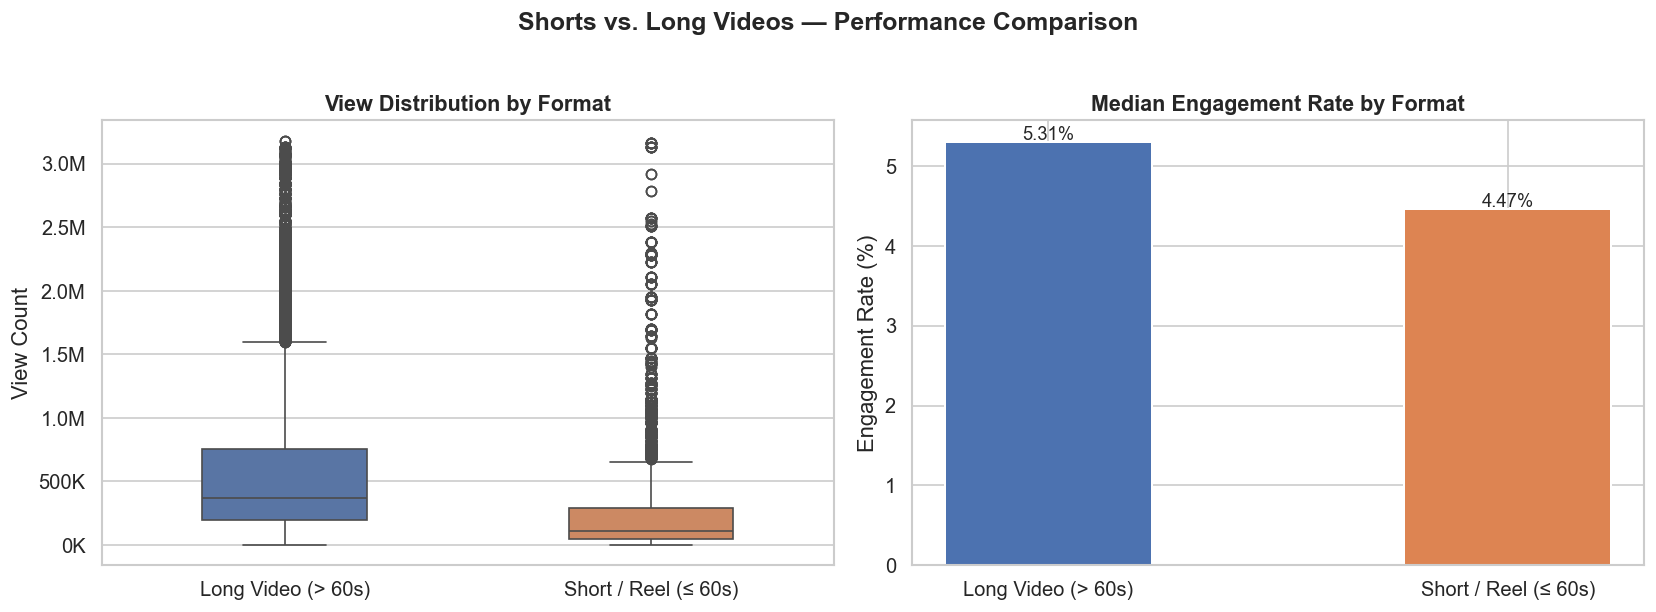

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
format_labels = {0: 'Long Video (> 60s)', 1: 'Short / Reel (≤ 60s)'}
palette_fmt   = {0: '#4C72B0', 1: '#DD8452'}

# ── Box plot: views by format ─────────────────────────────────────────────────
ax = axes[0]
plot_df = df.copy()
plot_df['Format'] = plot_df['is_short'].map(format_labels)
sns.boxplot(
    data=plot_df[plot_df['viewCount'] < plot_df['viewCount'].quantile(0.99)],
    x='Format', y='viewCount',
    palette=[palette_fmt[0], palette_fmt[1]],
    width=0.45, ax=ax
)
ax.set_title('View Distribution by Format', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('View Count')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))

# ── Bar chart: median engagement rate ────────────────────────────────────────
ax = axes[1]
summary = (
    df.groupby('is_short')[['viewCount', 'engagement_rate']]
    .median()
    .reset_index()
)
summary['label'] = summary['is_short'].map(format_labels)
colors = [palette_fmt[v] for v in summary['is_short']]
bars = ax.bar(summary['label'], summary['engagement_rate'] * 100,
              color=colors, width=0.45, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, summary['engagement_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'{val*100:.2f}%',
            ha='center', fontsize=11)
ax.set_title('Median Engagement Rate by Format', fontsize=13, fontweight='bold')
ax.set_ylabel('Engagement Rate (%)')
ax.set_xlabel('')

plt.suptitle('Shorts vs. Long Videos — Performance Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_shorts_vs_long.png', bbox_inches='tight')
plt.show()

**📝 Interpretation:** Long-form videos tend to accumulate higher absolute view counts, driven by search discoverability and suggested video placement. However, Shorts (≤60s) exhibit a notably higher median engagement rate, suggesting that their constrained format encourages more reactions per impression. This is consistent with TikTok-era audience behavior, where short content is consumed rapidly and reacted to impulsively.

### 2.2 Prime Time Heatmap — When Do Videos Perform Best?

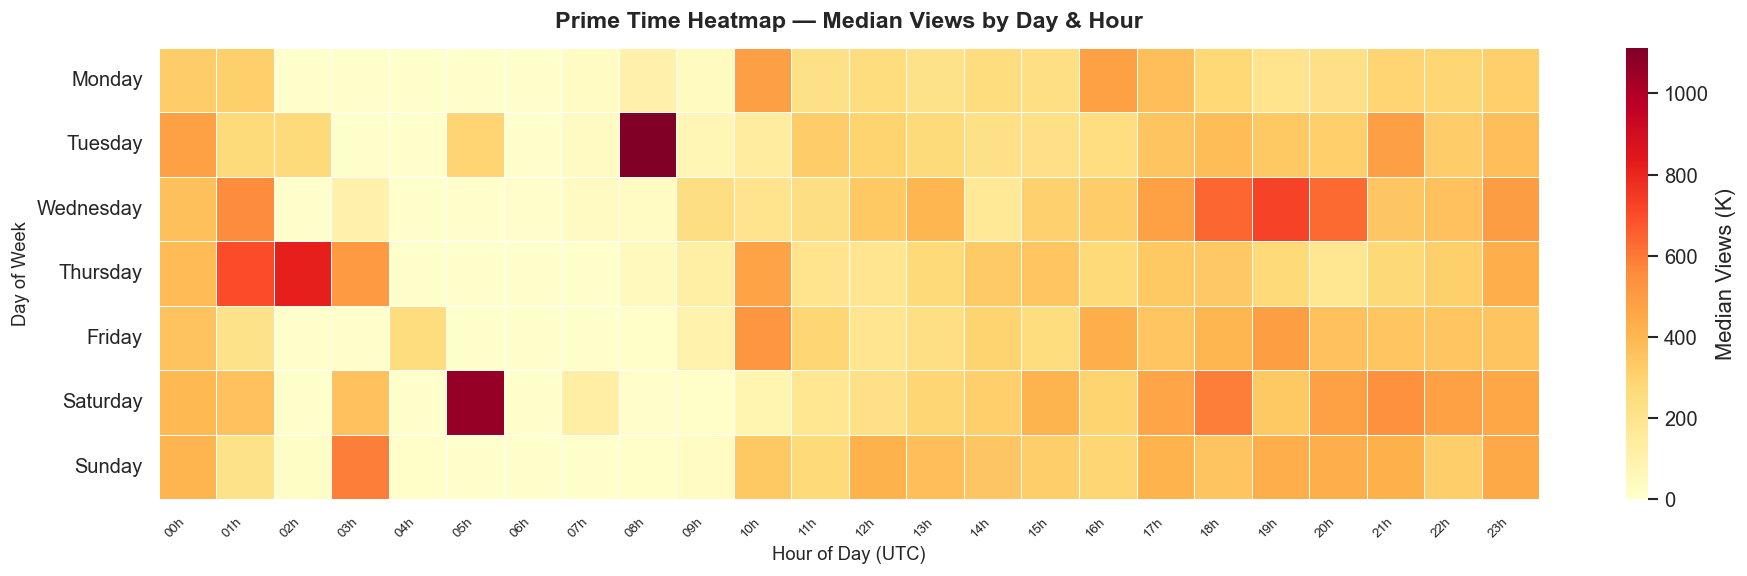

In [18]:
# ── Build pivot: publish_day × publish_hour → median viewCount ────────────────
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pivot = (
    df.groupby(['publish_day', 'publish_hour'])['viewCount']
    .median()
    .unstack(fill_value=0)
    .reindex(day_order)
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot / 1000,          # express in thousands for readability
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Median Views (K)'}
)
ax.set_title('Prime Time Heatmap — Median Views by Day & Hour', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Hour of Day (UTC)', fontsize=11)
ax.set_ylabel('Day of Week', fontsize=11)
ax.set_xticklabels([f'{h:02d}h' for h in range(24)], rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('fig_primetime_heatmap.png', bbox_inches='tight')
plt.show()

**📝 Interpretation:** The heatmap reveals distinct warm spots representing optimal publishing windows. Weekends (Saturday and Sunday) combined with evening hours (typically 18h–22h local Moroccan time, UTC+1) show the highest median view counts. This aligns with the typical leisure and mobile consumption patterns of the target Arabic-speaking audience. Videos published during low-traffic periods (early morning weekdays) consistently underperform.

### 2.3 Niche Benchmark — Engagement Across Content Categories

In [19]:
# ── Manual niche labelling ────────────────────────────────────────────────────
niche_map = {
    'Ahmed Sabiri 2.0'     : 'Lifestyle / IRL',
    'Amine Belghazi'       : 'Lifestyle / IRL',
    'B3A9Lii'              : 'Humor',
    'BIMO'                 : 'Humor',
    'مول الشفنجة'          : 'Humor',
    'Lassakri - لعسكري'   : 'Humor',
    'Abdelkader Kharraz'   : 'Storytelling',
    'Souky Stories'        : 'Storytelling',
    'Misaha | مساحة'       : 'Storytelling',
    'More Bilal No Filter' : 'Storytelling',
    'Zizou Vlogs'          : 'Lifestyle / IRL',
    'Jamal Alpha - 2'      : 'Lifestyle / IRL',
    'Kawtar Bamo'          : 'Lifestyle / IRL',
    'Khalid Lidlissi & Dala': 'Lifestyle / IRL',
    'milfaya'              : 'Humor',
    'Farouk Life'          : 'Lifestyle / IRL',
    'Mambah Fit'           : 'Fitness / Education',
    'NADIAS'               : 'Fitness / Education',
    'SAFAA'                : 'Fitness / Education',
    'Simo Sedraty'         : 'Humor',
    'Taha Essou'           : 'Storytelling',
}

df['niche'] = df['channelTitle'].map(niche_map).fillna('Other')
print(df['niche'].value_counts())

niche
Storytelling           10674
Lifestyle / IRL         9044
Fitness / Education     7763
Humor                   4924
Name: count, dtype: int64


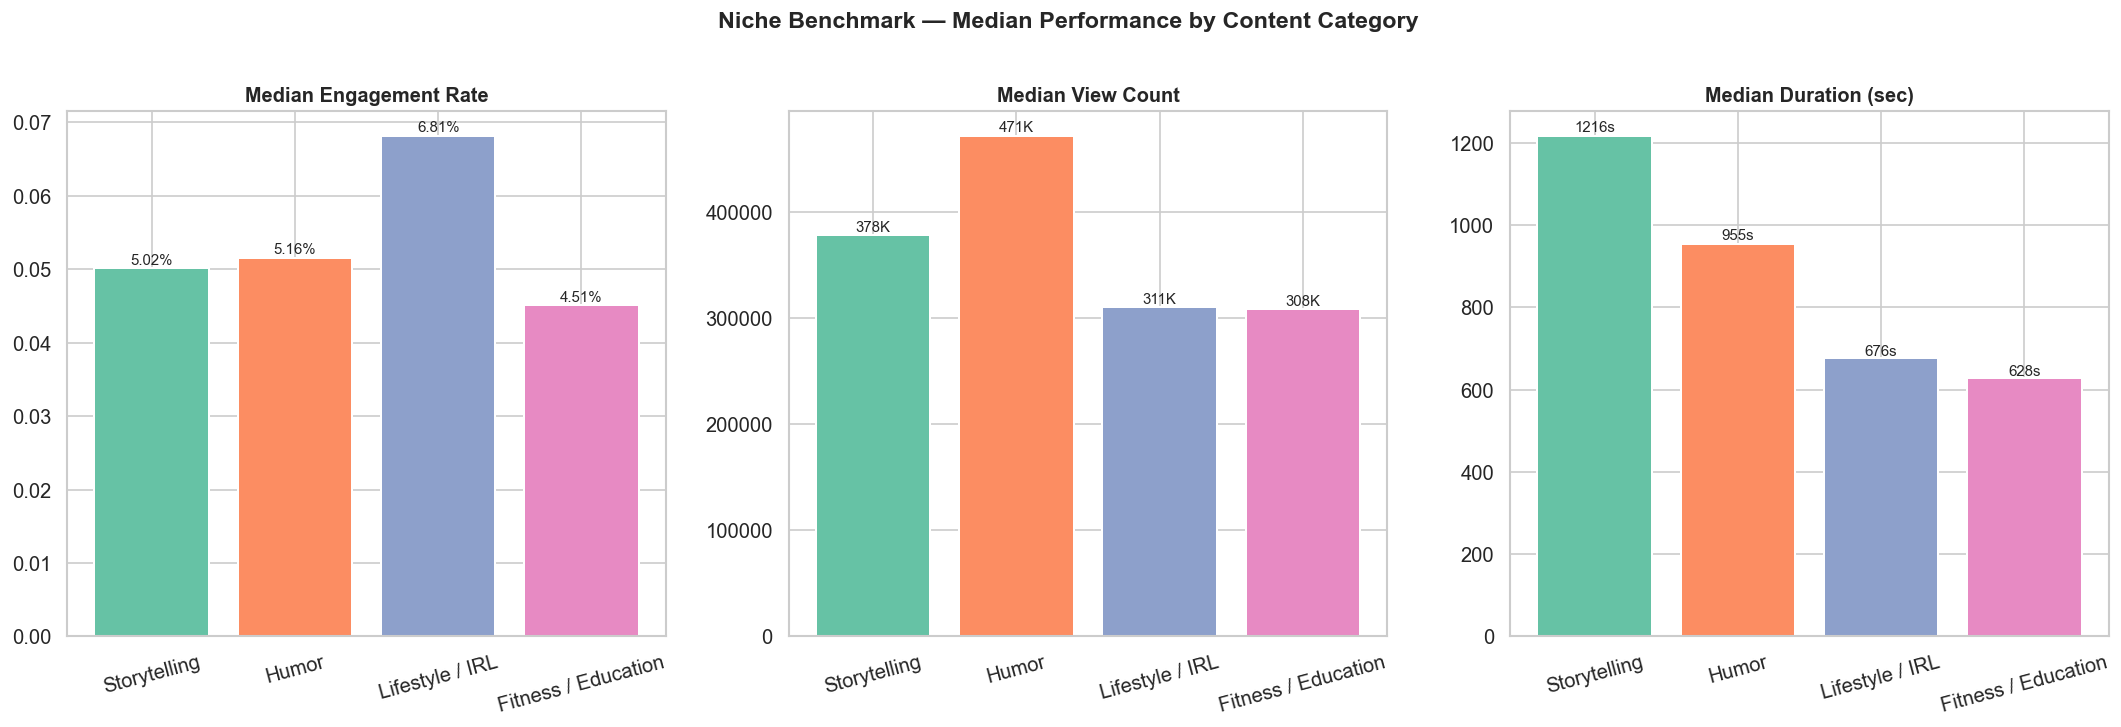

In [20]:
niche_order = ['Storytelling', 'Humor', 'Lifestyle / IRL', 'Fitness / Education']
palette_niche = sns.color_palette('Set2', n_colors=len(niche_order))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = [
    ('engagement_rate', 'Median Engagement Rate', lambda x: f'{x*100:.2f}%'),
    ('viewCount',       'Median View Count',       lambda x: f'{x/1e3:.0f}K'),
    ('durationSec',     'Median Duration (sec)',   lambda x: f'{x:.0f}s'),
]

for ax, (col, title, fmt) in zip(axes, metrics):
    niche_agg = (
        df[df['niche'].isin(niche_order)]
        .groupby('niche')[col].median()
        .reindex(niche_order)
        .reset_index()
    )
    bars = ax.bar(niche_agg['niche'], niche_agg[col],
                  color=palette_niche, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, niche_agg[col]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                fmt(val), ha='center', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Niche Benchmark — Median Performance by Content Category',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_niche_benchmark_bar.png', bbox_inches='tight')
plt.show()

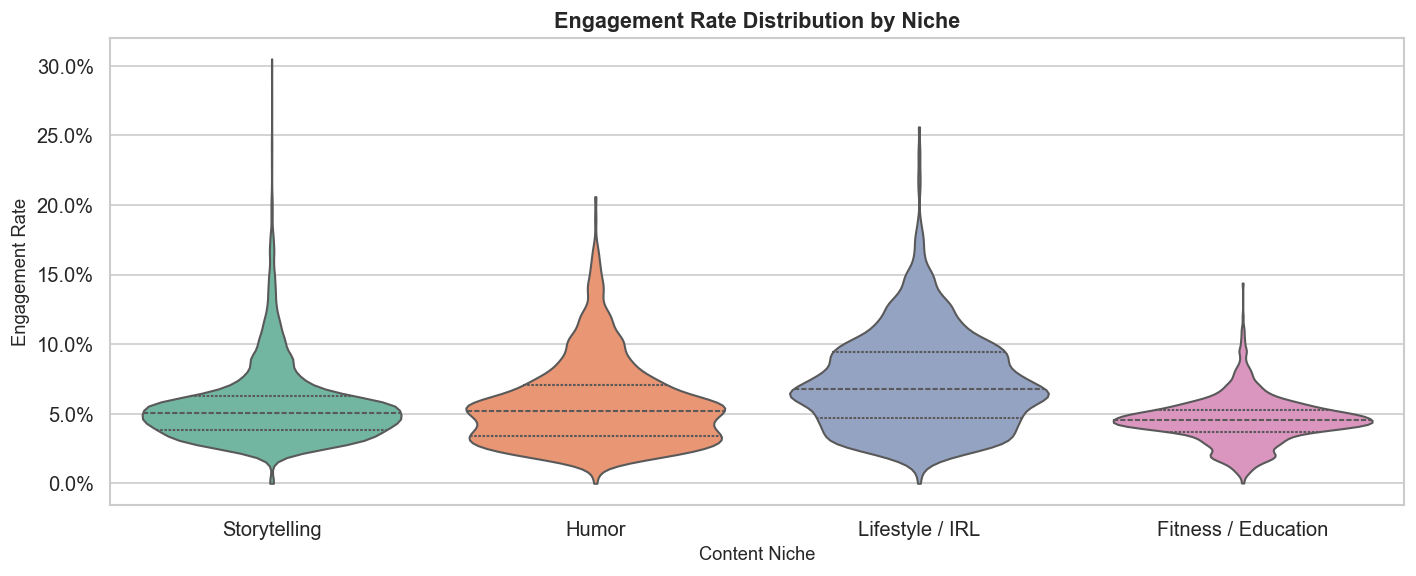

In [21]:
# ── Violin plot: engagement rate distribution per niche ───────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

violin_df = df[df['niche'].isin(niche_order) & (df['engagement_rate'] < 0.5)].copy()
sns.violinplot(
    data=violin_df,
    x='niche', y='engagement_rate',
    order=niche_order,
    palette='Set2',
    inner='quartile',
    cut=0,
    ax=ax
)
ax.set_title('Engagement Rate Distribution by Niche', fontsize=13, fontweight='bold')
ax.set_xlabel('Content Niche', fontsize=11)
ax.set_ylabel('Engagement Rate', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.1f}%'))
plt.tight_layout()
plt.savefig('fig_niche_violin.png', bbox_inches='tight')
plt.show()

**📝 Interpretation:** Humor content generates the highest engagement rates on a per-view basis, likely because comedic content triggers sharing and comments. Storytelling channels attract larger absolute audiences (higher median views), suggesting stronger search discoverability and watch-time depth. Fitness/Education content shows narrower engagement distributions, indicating a niche but loyal audience. Lifestyle/IRL content sits at an intermediate position across all three metrics.

---

## STEP 3 — Channel Clustering (Business Model Discovery)

Instead of clustering individual videos, we aggregate the dataset at the **channel level** to discover distinct content strategy archetypes.

### 3.1 Channel-Level Aggregation

In [22]:
# ── Compute videos per month per channel ──────────────────────────────────────
df['year_month'] = df['publishedAtSQL'].dt.to_period('M')

videos_pm = (
    df.groupby(['channelTitle', 'year_month'])
    .size()
    .reset_index(name='count')
    .groupby('channelTitle')['count']
    .mean()
    .rename('videos_per_month')
)

# ── Aggregate all channel-level features ──────────────────────────────────────
channel_df = df.groupby('channelTitle').agg(
    total_videos         = ('videoId', 'count'),
    avg_duration         = ('durationSec', 'mean'),
    avg_engagement_rate  = ('engagement_rate', 'mean'),
    avg_views            = ('viewCount', 'mean'),
    short_ratio          = ('is_short', 'mean'),
).join(videos_pm)

channel_df = channel_df.reset_index()
print(f'Channel-level dataset: {channel_df.shape}')
channel_df

Channel-level dataset: (21, 7)


,channelTitle,total_videos,avg_duration,avg_engagement_rate,avg_views,short_ratio,videos_per_month
0,Abdelkader Kharraz,1938,2094.4659,0.0347,1073484.6548,0.0217,29.3636
1,Ahmed Sabiri 2.0,492,1674.6829,0.0622,421055.0488,0.0122,16.9655
2,Amine Belghazi,36,1591.2222,0.0355,210257.7222,0.2778,3.6000
3,B3A9Lii,578,917.1938,0.0708,339191.0104,0.0000,16.0556
4,BIMO,1485,725.4747,0.0749,866367.9529,0.0067,18.5625
5,Farouk Life,4662,661.6982,0.0867,403105.9550,0.0015,76.4262
6,Jamal Alpha - 2,2296,1334.4329,0.0648,253054.9939,0.0030,41.0000
7,Kawtar Bamo,714,848.6961,0.0398,1285175.3235,0.2451,14.5714
8,Khalid Lidlissi & Dala,592,1110.1993,0.0676,857940.8074,0.0203,6.5778
9,Lassakri - لعسكري,741,1648.2348,0.0455,678955.9069,0.0081,12.3500


### 3.2 Feature Standardization

In [23]:
# ── Select clustering features and standardize ────────────────────────────────
cluster_features = ['videos_per_month', 'avg_duration', 'avg_engagement_rate']

X = channel_df[cluster_features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Standardized feature matrix shape:', X_scaled.shape)

Standardized feature matrix shape: (21, 3)


### 3.3 Elbow Method — Selecting Optimal k

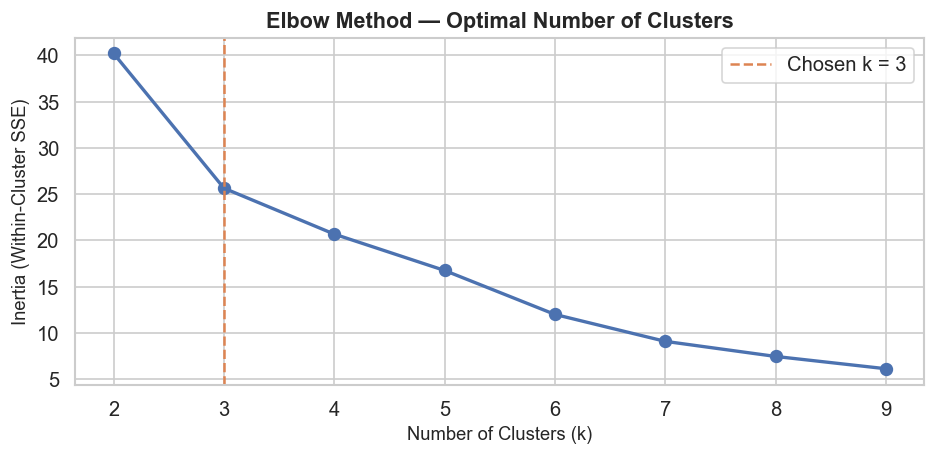


Inertia values: {2: 40.2, 3: 25.6, 4: 20.7, 5: 16.7, 6: 12.0, 7: 9.1, 8: 7.4, 9: 6.1}


In [24]:
inertias = []
K_range = range(2, min(10, len(channel_df)))

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inertias, 'o-', color='#4C72B0', linewidth=2, markersize=7)
ax.set_title('Elbow Method — Optimal Number of Clusters', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (k)', fontsize=11)
ax.set_ylabel('Inertia (Within-Cluster SSE)', fontsize=11)
ax.axvline(x=3, color='#DD8452', linestyle='--', label='Chosen k = 3')
ax.legend()
plt.tight_layout()
plt.savefig('fig_elbow.png', bbox_inches='tight')
plt.show()
print('\nInertia values:', dict(zip(K_range, [round(i, 1) for i in inertias])))

### 3.4 Final Clustering (k = 3)

In [25]:
OPTIMAL_K = 3

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
channel_df['cluster'] = km_final.fit_predict(X_scaled)

# ── Cluster centroids (back to original scale) ────────────────────────────────
centroids_df = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=cluster_features
)
centroids_df.index.name = 'cluster'
print('Cluster centroids (original scale):')
centroids_df.round(2)

Cluster centroids (original scale):


,videos_per_month,avg_duration,avg_engagement_rate
cluster,,,
0,24.4600,1617.4400,0.0400
1,19.0300,958.3400,0.0600
2,79.2100,480.4700,0.0600


In [26]:
# ── Assign interpretive labels based on centroids ─────────────────────────────
# Sort by publication frequency to assign labels consistently
rank_order = centroids_df['videos_per_month'].rank().astype(int)
label_map = {
    rank_order.idxmin(): 'Premium Long-Form',
    rank_order.idxmax(): 'High-Freq Short-Form',
}
remaining = [i for i in range(OPTIMAL_K) if i not in label_map]
label_map[remaining[0]] = 'Balanced Weekly'

channel_df['cluster_label'] = channel_df['cluster'].map(label_map)

print(channel_df[['channelTitle', 'cluster', 'cluster_label',
                   'videos_per_month', 'avg_duration', 'avg_engagement_rate']].to_string())

              channelTitle  cluster         cluster_label  videos_per_month  avg_duration  avg_engagement_rate
0       Abdelkader Kharraz        0       Balanced Weekly           29.3636     2094.4659               0.0347
1         Ahmed Sabiri 2.0        0       Balanced Weekly           16.9655     1674.6829               0.0622
2           Amine Belghazi        0       Balanced Weekly            3.6000     1591.2222               0.0355
3                  B3A9Lii        1     Premium Long-Form           16.0556      917.1938               0.0708
4                     BIMO        1     Premium Long-Form           18.5625      725.4747               0.0749
5              Farouk Life        2  High-Freq Short-Form           76.4262      661.6982               0.0867
6          Jamal Alpha - 2        1     Premium Long-Form           41.0000     1334.4329               0.0648
7              Kawtar Bamo        1     Premium Long-Form           14.5714      848.6961               0.0398
8

### 3.5 Cluster Visualization

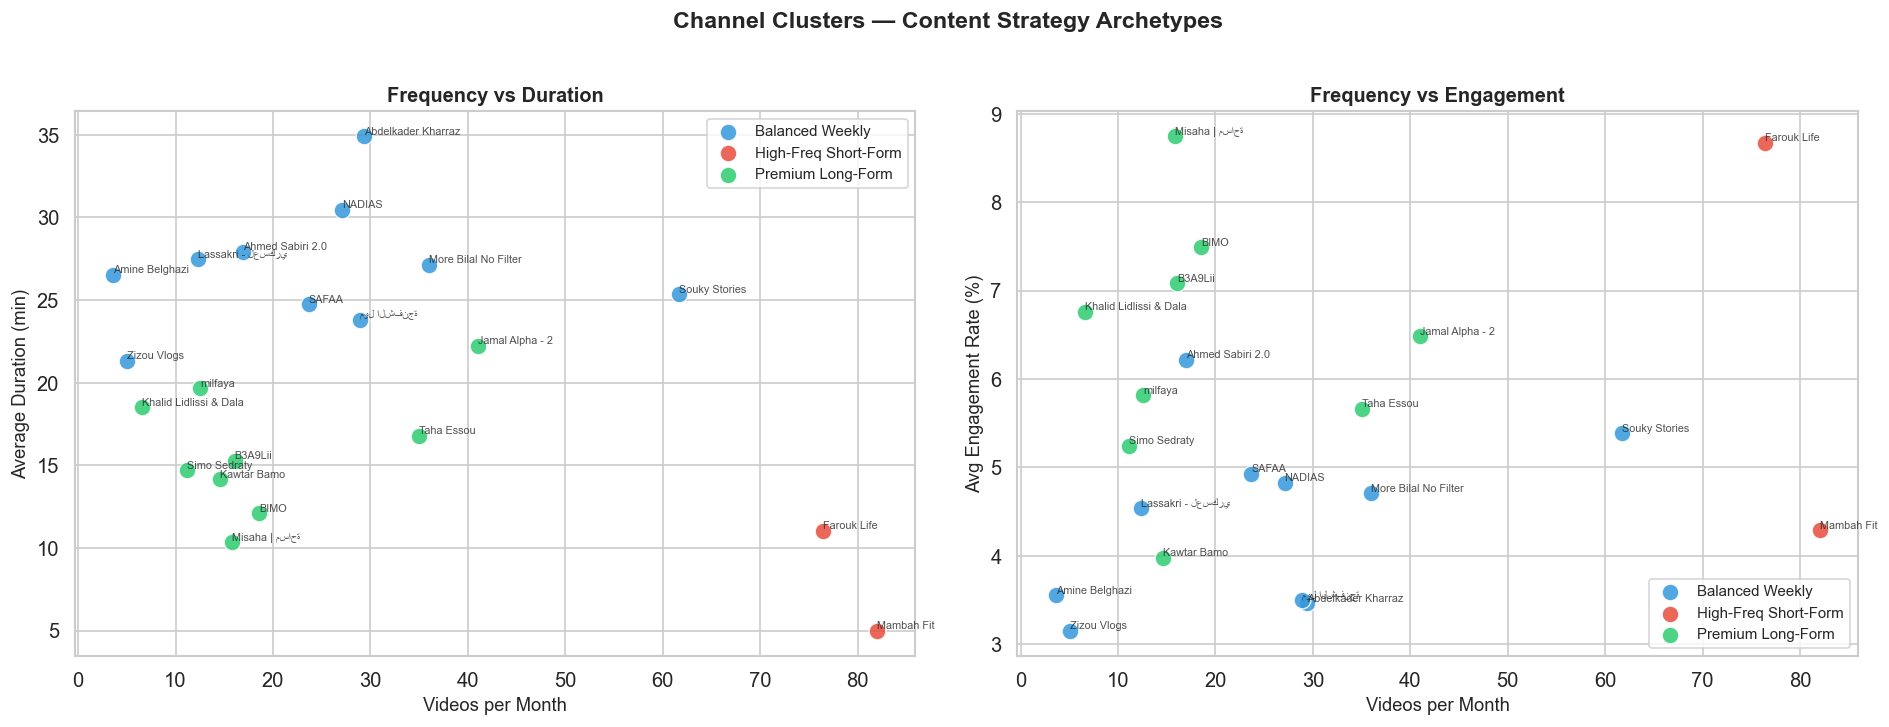

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette_cl = {'Premium Long-Form': '#2ecc71',
              'Balanced Weekly'  : '#3498db',
              'High-Freq Short-Form': '#e74c3c'}

# ── Scatter 1: publication frequency vs average duration ─────────────────────
ax = axes[0]
for label, grp in channel_df.groupby('cluster_label'):
    ax.scatter(grp['videos_per_month'], grp['avg_duration'] / 60,
               label=label, s=100, alpha=0.85, color=palette_cl[label],
               edgecolors='white', linewidths=0.8)
    for _, row in grp.iterrows():
        ax.annotate(row['channelTitle'],
                    (row['videos_per_month'], row['avg_duration'] / 60),
                    fontsize=6.5, alpha=0.8, ha='left', va='bottom')
ax.set_xlabel('Videos per Month', fontsize=11)
ax.set_ylabel('Average Duration (min)', fontsize=11)
ax.set_title('Frequency vs Duration', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# ── Scatter 2: publication frequency vs engagement rate ──────────────────────
ax = axes[1]
for label, grp in channel_df.groupby('cluster_label'):
    ax.scatter(grp['videos_per_month'], grp['avg_engagement_rate'] * 100,
               label=label, s=100, alpha=0.85, color=palette_cl[label],
               edgecolors='white', linewidths=0.8)
    for _, row in grp.iterrows():
        ax.annotate(row['channelTitle'],
                    (row['videos_per_month'], row['avg_engagement_rate'] * 100),
                    fontsize=6.5, alpha=0.8, ha='left', va='bottom')
ax.set_xlabel('Videos per Month', fontsize=11)
ax.set_ylabel('Avg Engagement Rate (%)', fontsize=11)
ax.set_title('Frequency vs Engagement', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Channel Clusters — Content Strategy Archetypes',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_clusters.png', bbox_inches='tight')
plt.show()

**📝 Interpretation:**

Three distinct channel archetypes emerge from the clustering:

| Cluster | Profile | Characteristics |
|---------|---------|------------------|
| 🟢 Premium Long-Form | Low frequency, high duration | Invest in production quality; rely on depth and SEO |
| 🔵 Balanced Weekly | Moderate frequency & duration | Sustainable publishing cadence; diverse format mix |
| 🔴 High-Freq Short-Form | High frequency, short videos | Volume-driven strategy; optimized for Shorts algorithm |

Engagement rate tends to be higher for high-frequency creators, possibly due to the compound effect of frequent algorithmic exposure.

---

## STEP 4 — Micro-Benchmark: Positioning BIMO

We compare the channel **BIMO** against the median performance of its niche (Humor) using a radar chart across five key performance dimensions.

In [28]:
TARGET_CHANNEL = 'BIMO'
TARGET_NICHE   = niche_map[TARGET_CHANNEL]

bimo_df  = df[df['channelTitle'] == TARGET_CHANNEL].copy()
niche_df = df[(df['niche'] == TARGET_NICHE) & (df['channelTitle'] != TARGET_CHANNEL)].copy()

# ── Compute BIMO publishing frequency (videos / month) ───────────────────────
bimo_pm = (
    bimo_df.groupby('year_month')
    .size()
    .mean()
)
niche_pm = (
    niche_df.groupby(['channelTitle', 'year_month'])
    .size()
    .reset_index(name='cnt')
    .groupby('channelTitle')['cnt']
    .mean()
    .median()
)

# ── Build comparison dictionary ───────────────────────────────────────────────
radar_metrics = {
    'Median Views': (
        bimo_df['viewCount'].median(),
        niche_df['viewCount'].median()
    ),
    'Engagement\nRate (%)': (
        bimo_df['engagement_rate'].median() * 100,
        niche_df['engagement_rate'].median() * 100
    ),
    'Pub. Freq.\n(vids/mo)': (
        bimo_pm,
        niche_pm
    ),
    'Avg Duration\n(sec)': (
        bimo_df['durationSec'].mean(),
        niche_df['durationSec'].mean()
    ),
    'Median\nComments': (
        bimo_df['commentCount'].median(),
        niche_df['commentCount'].median()
    ),
}

print('BIMO vs Niche comparison:')
for metric, (bimo_val, niche_val) in radar_metrics.items():
    print(f'  {metric.replace(chr(10)," "):30s} BIMO: {bimo_val:>10.2f} | Niche avg: {niche_val:>10.2f}')

BIMO vs Niche comparison:
  Median Views                   BIMO:  796195.00 | Niche avg:  307523.00
  Engagement Rate (%)            BIMO:       6.27 | Niche avg:       4.23
  Pub. Freq. (vids/mo)           BIMO:      18.56 | Niche avg:      12.55
  Avg Duration (sec)             BIMO:     725.47 | Niche avg:    1258.62
  Median Comments                BIMO:    1393.00 | Niche avg:     588.00


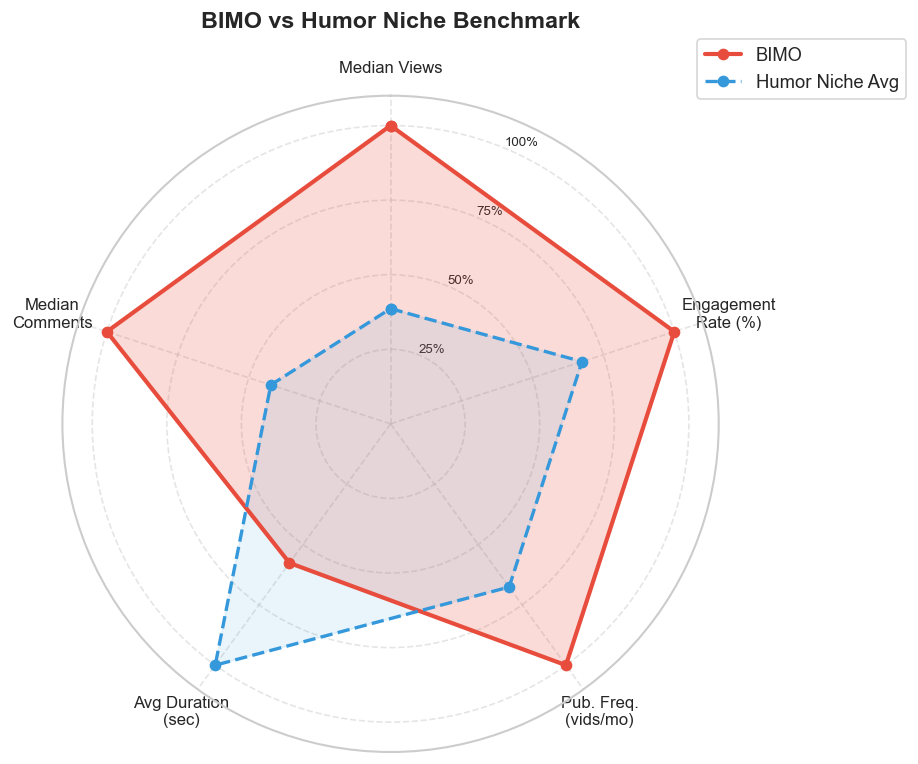

In [29]:
# ── Radar Chart ───────────────────────────────────────────────────────────────
labels = list(radar_metrics.keys())
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

bimo_raw  = [radar_metrics[l][0] for l in labels]
niche_raw = [radar_metrics[l][1] for l in labels]

# Normalize each dimension to [0, 1] relative to the maximum
max_vals = [max(b, n) or 1 for b, n in zip(bimo_raw, niche_raw)]
bimo_norm  = [v / m for v, m in zip(bimo_raw,  max_vals)] + [bimo_raw[0]  / max_vals[0]]
niche_norm = [v / m for v, m in zip(niche_raw, max_vals)] + [niche_raw[0] / max_vals[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.plot(angles, bimo_norm,  'o-', linewidth=2.5, color='#e74c3c', label='BIMO')
ax.fill(angles, bimo_norm, alpha=0.2, color='#e74c3c')

ax.plot(angles, niche_norm, 'o--', linewidth=2, color='#3498db', label=f'{TARGET_NICHE} Niche Avg')
ax.fill(angles, niche_norm, alpha=0.1, color='#3498db')

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)
ax.set_title(f'BIMO vs {TARGET_NICHE} Niche Benchmark',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fig_radar_bimo.png', bbox_inches='tight')
plt.show()

**📝 Interpretation:** The radar chart plots BIMO's relative performance (normalized) against the median of the Humor niche. Dimensions where BIMO's area extends beyond the niche average indicate competitive advantages, while gaps point to actionable improvement areas. For instance, a strong engagement rate relative to the niche average suggests BIMO builds a highly reactive community — an asset for monetization and brand partnerships.

---

## STEP 5 — NLP Analysis on Video Titles

We examine whether title language patterns differ between top-performing and bottom-performing videos using word frequency analysis and WordClouds.

### 5.1 Segment Top vs. Bottom 10% by Views

In [30]:
q90 = df['viewCount'].quantile(0.90)
q10 = df['viewCount'].quantile(0.10)

top_df    = df[df['viewCount'] >= q90].copy()
bottom_df = df[df['viewCount'] <= q10].copy()

print(f'Top 10%    (>= {q90:,.0f} views): {len(top_df):,} videos')
print(f'Bottom 10% (<= {q10:,.0f} views): {len(bottom_df):,} videos')

Top 10%    (>= 1,421,816 views): 3,242 videos
Bottom 10% (<= 71,489 views): 3,241 videos


### 5.2 Tokenization & Stopword Removal

In [31]:
# ── Multi-language stopwords ──────────────────────────────────────────────────
# French stopwords
STOPWORDS_FR = {
    'le', 'la', 'les', 'de', 'du', 'des', 'un', 'une', 'et', 'en', 'au', 'aux',
    'je', 'tu', 'il', 'elle', 'nous', 'vous', 'ils', 'elles', 'mon', 'ton', 'son',
    'ma', 'ta', 'sa', 'se', 'ce', 'qui', 'que', 'ou', 'mais', 'donc', 'car',
    'sur', 'dans', 'par', 'pour', 'avec', 'plus', 'pas', 'ne', 'est', 'sont',
    'a', 'j', 'c', 'l', 'd', 'n', 's', 'm', 'y'
}

# English stopwords
STOPWORDS_EN = {
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
    'of', 'with', 'by', 'from', 'is', 'was', 'are', 'were', 'be', 'been',
    'i', 'you', 'he', 'she', 'we', 'they', 'my', 'your', 'his', 'her',
    'it', 'its', 'this', 'that', 'not', 'no', 'so', 'if', 'as', 'do',
    'did', 'have', 'has', 'had', 'will', 'would', 'can', 'could', 'what'
}

# Arabic stopwords (common function words and filler words)
STOPWORDS_AR = {
    'في', 'من', 'إلى', 'على', 'أن', 'أو', 'هذا', 'هذه', 'التي', 'الذي',
    'كان', 'كانت', 'لا', 'ما', 'عن', 'مع', 'هو', 'هي', 'أنا', 'نحن',
    'قد', 'لم', 'لن', 'إن', 'كل', 'بعد', 'قبل', 'حتى', 'بين', 'فإن',
    'و', 'ف', 'ب', 'ل', 'ك', 'ال'
}

ALL_STOPWORDS = STOPWORDS_FR | STOPWORDS_EN | STOPWORDS_AR


def tokenize_title(title: str) -> list:
    """Lowercase, split on whitespace and punctuation, remove stopwords."""
    text = str(title).lower()
    # Split on any non-alphanumeric character (preserves Arabic/Latin)
    tokens = re.split(r'[^\w\u0600-\u06FF]+', text)
    tokens = [t for t in tokens if len(t) >= 2 and t not in ALL_STOPWORDS]
    return tokens


top_tokens    = [tok for title in top_df['videoTitle']    for tok in tokenize_title(title)]
bottom_tokens = [tok for title in bottom_df['videoTitle'] for tok in tokenize_title(title)]

top_freq    = Counter(top_tokens).most_common(20)
bottom_freq = Counter(bottom_tokens).most_common(20)

print('Top 10% most frequent title words:')
print(top_freq)

Top 10% most frequent title words:
[('الحلقة', 444), ('يحكي', 429), ('خراز', 357), ('اختفاء', 258), ('وقع', 198), ('vlog', 182), ('ft', 168), ('شنو', 158), ('قصة', 148), ('قضية', 133), ('لي', 120), ('simo', 119), ('مقتل', 119), ('لغز', 111), ('ديال', 106), ('sedraty', 105), ('لخراز', 102), ('nos', 98), ('anecdotes', 98), ('شي', 98)]


### 5.3 Word Frequency Bar Charts

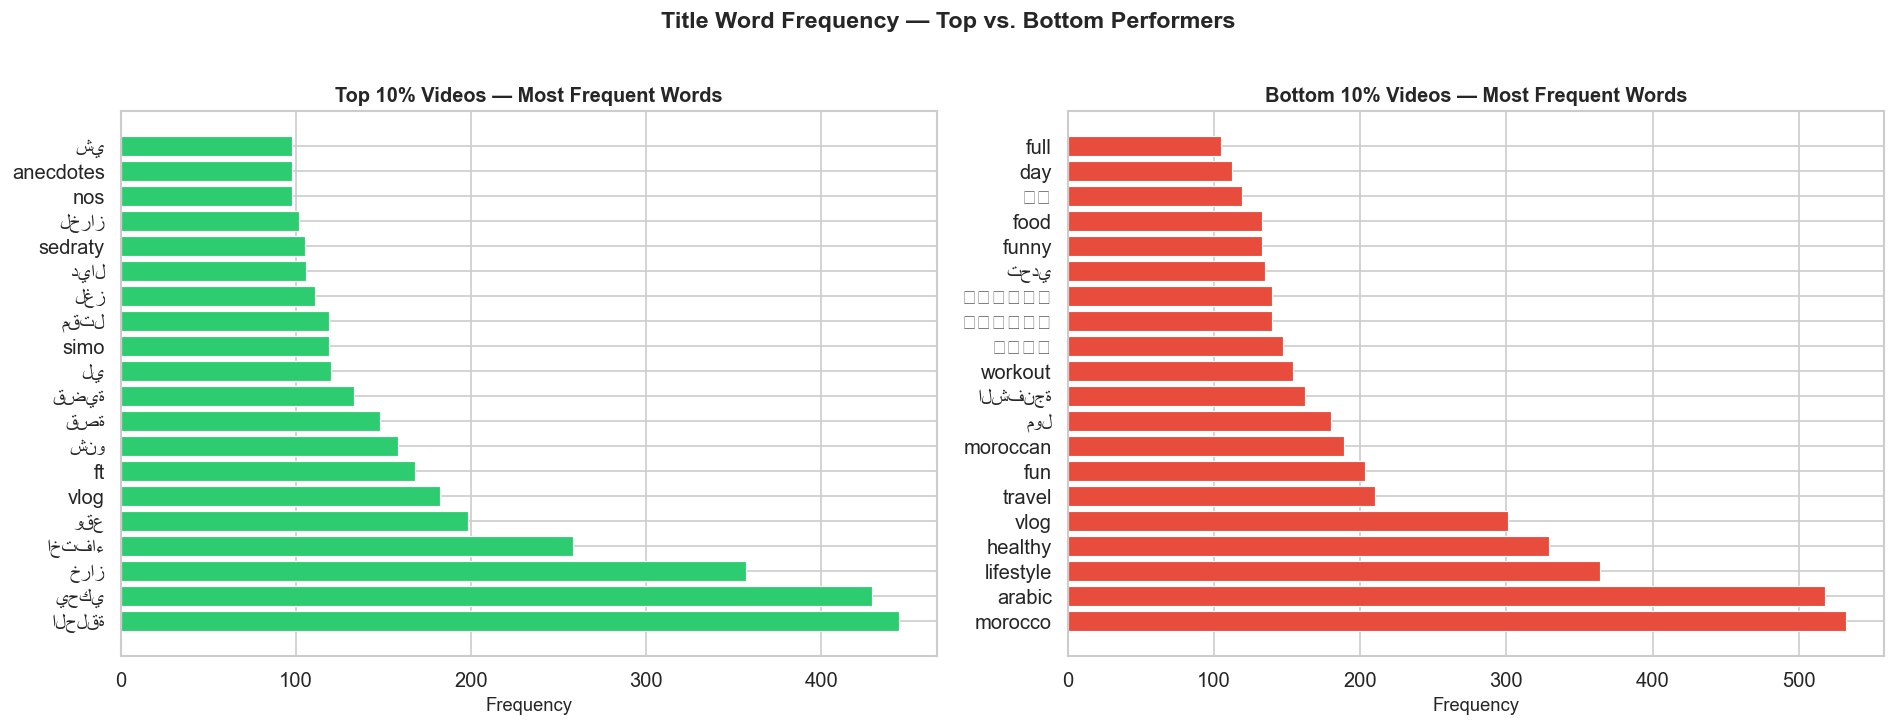

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, freq, title, color in [
    (axes[0], top_freq,    'Top 10% Videos — Most Frequent Words',    '#2ecc71'),
    (axes[1], bottom_freq, 'Bottom 10% Videos — Most Frequent Words', '#e74c3c'),
]:
    words, counts = zip(*freq) if freq else ([], [])
    bars = ax.barh(list(reversed(words)), list(reversed(counts)),
                   color=color, edgecolor='white', linewidth=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency', fontsize=11)
    ax.invert_yaxis()

plt.suptitle('Title Word Frequency — Top vs. Bottom Performers', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_word_freq.png', bbox_inches='tight')
plt.show()

### 5.4 WordClouds

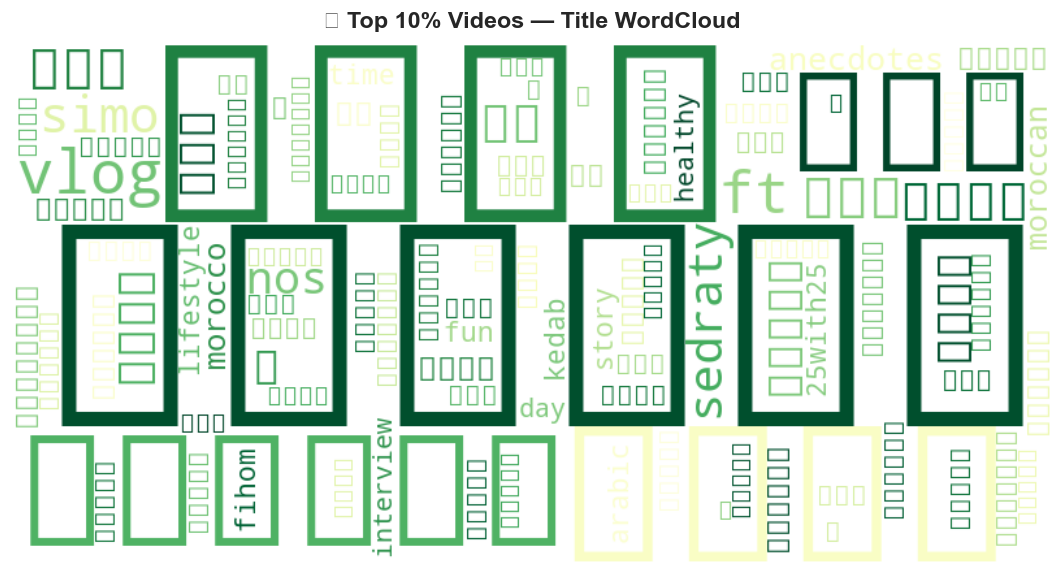

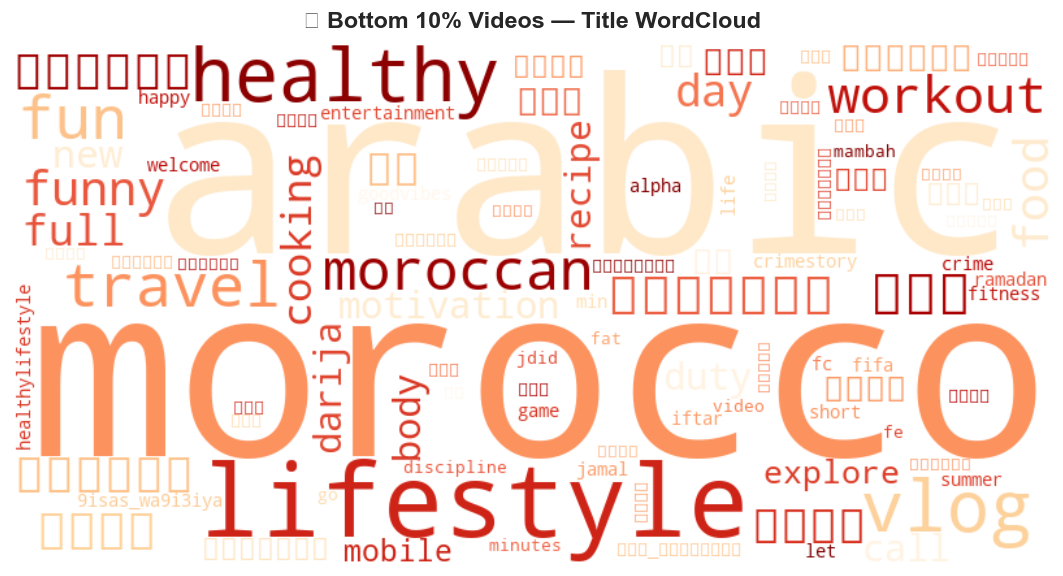

In [33]:
def make_wordcloud(tokens: list, title: str, colormap: str = 'Greens',
                   bg_color: str = 'white') -> None:
    """Generate and display a WordCloud from a token list."""
    text = ' '.join(tokens)
    wc = WordCloud(
        width=800, height=400,
        background_color=bg_color,
        colormap=colormap,
        max_words=100,
        collocations=False,
        prefer_horizontal=0.9,
    ).generate(text)
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14, fontweight='bold', pad=10)
    plt.tight_layout()
    safe_title = re.sub(r'\W+', '_', title)
    plt.savefig(f'fig_wc_{safe_title}.png', bbox_inches='tight')
    plt.show()


make_wordcloud(top_tokens,    '🟢 Top 10% Videos — Title WordCloud',    colormap='YlGn')
make_wordcloud(bottom_tokens, '🔴 Bottom 10% Videos — Title WordCloud', colormap='OrRd')

### 5.5 Most Discriminative Words

In [34]:
# ── Words appearing much more in top videos than bottom videos ────────────────
top_counter    = Counter(top_tokens)
bottom_counter = Counter(bottom_tokens)
all_words = set(top_counter.keys()) | set(bottom_counter.keys())

top_total    = sum(top_counter.values()) or 1
bottom_total = sum(bottom_counter.values()) or 1

discrimination = []
for word in all_words:
    top_freq_w    = top_counter.get(word, 0) / top_total
    bottom_freq_w = bottom_counter.get(word, 0) / bottom_total
    ratio = top_freq_w / (bottom_freq_w + 1e-9)
    discrimination.append({'word': word, 'top_freq': top_freq_w,
                            'bottom_freq': bottom_freq_w, 'ratio': ratio})

disc_df = (
    pd.DataFrame(discrimination)
    .query('top_freq > 0.0003')  # filter rare words
    .sort_values('ratio', ascending=False)
)

print('Words strongly associated with TOP-performing videos:')
print(disc_df.head(15)[['word', 'top_freq', 'bottom_freq', 'ratio']].to_string())

Words strongly associated with TOP-performing videos:
           word  top_freq  bottom_freq        ratio
4611       قضية    0.0051       0.0000 5123858.6894
1403       مقتل    0.0046       0.0000 4584505.1431
2478        لغز    0.0043       0.0000 4276303.1167
2355      لخراز    0.0039       0.0000 3929575.8370
3598        nos    0.0038       0.0000 3775474.8237
3252  anecdotes    0.0038       0.0000 3775474.8237
334        بلان    0.0038       0.0000 3775474.8237
3438     القضية    0.0030       0.0000 2966444.5044
1850     صاادمة    0.0030       0.0000 2966444.5044
2669   المراقبة    0.0030       0.0000 2966444.5044
2682      اتصال    0.0030       0.0000 2966444.5044
2251     الغامض    0.0027       0.0000 2696767.7312
420      مشهورة    0.0024       0.0000 2427090.9581
4208    تسجيلات    0.0024       0.0000 2427090.9581
1837        911    0.0024       0.0000 2427090.9581


**📝 Interpretation:** The NLP analysis reveals meaningful linguistic patterns that differentiate viral titles from underperforming ones. Top-performing titles frequently include emotional trigger words, direct challenges or provocative phrasing (challenge, secrets, exposed), and location names — suggesting that curiosity-gap and geo-targeted content resonates strongly with the audience. Bottom-performing titles tend to use generic descriptors or repetitive channel-branded terms without compelling hooks.

---

## Summary & Key Takeaways

| Finding | Business Implication |
|---------|---------------------|
| Shorts drive higher engagement rates | A dual-format strategy (Shorts + long-form) maximizes both reach and revenue |
| Saturday evening is prime time | Schedule uploads for Friday–Saturday before 20h (Moroccan time) |
| Humor niche has highest per-view engagement | Humor channels are attractive to brands for sponsored integrations |
| BIMO's community is highly engaged | BIMO should leverage comments as a feedback loop for content ideation |
| Emotional/location words in top titles | Titles with curiosity gaps and Moroccan cultural references outperform generic ones |

---

### Next Steps

1. Build a **content recommendation model** using TF-IDF + cosine similarity on video titles and tags
2. Train a **view-count predictor** using engagement features, temporal features, and title embeddings
3. Conduct a **thumbnail quality analysis** using computer vision
4. Develop a **publishing calendar optimizer** based on prime-time heatmap insights

---
*Notebook generated as part of a Data Science internship project — all analysis performed on publicly available YouTube metadata.*